In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_amzn = pd.read_csv("./dataset/portfolio_data.csv")

In [3]:
data_amzn = data_amzn.drop(["DPZ", "BTC", "NFLX"], axis=1)

In [4]:
data_amzn.head()

,Date,AMZN
0,5/1/2013,248.229996
1,5/2/2013,252.550003
2,5/3/2013,258.049988
3,5/6/2013,255.720001
4,5/7/2013,257.730011


In [5]:
data_amzn.info()

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   str    
 1   AMZN    1520 non-null   float64
dtypes: float64(1), str(1)
memory usage: 23.9 KB


In [6]:
data_amzn.isnull().sum()

Date    0
AMZN    0
dtype: int64

In [7]:
data_amzn.shape

(1520, 2)

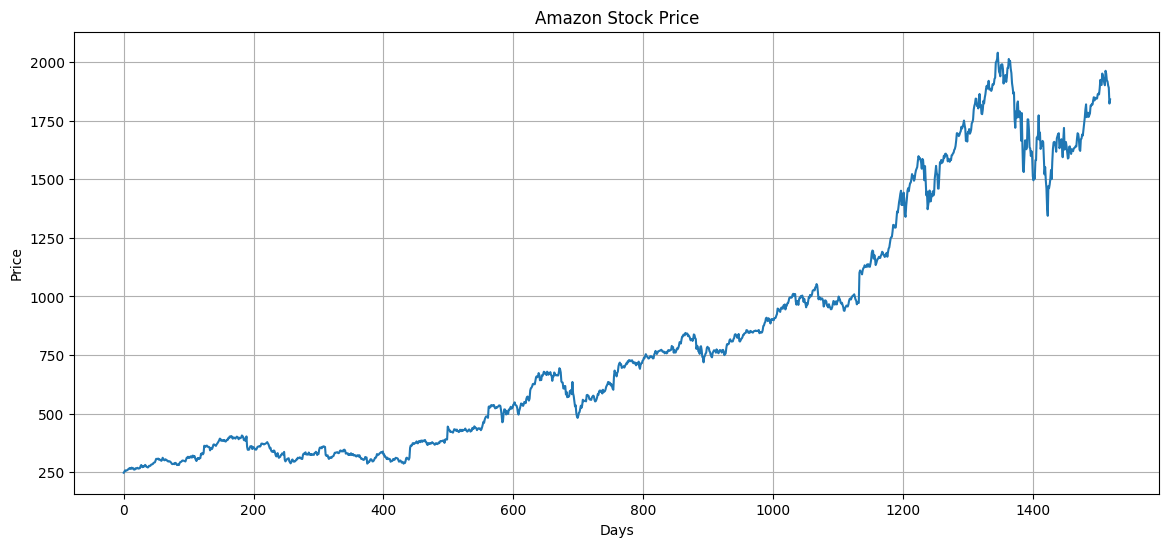

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(data_amzn['AMZN'])
plt.title("Amazon Stock Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid()
plt.show()

In [9]:
price = data_amzn["AMZN"].values
print(type(price))

<class 'numpy.ndarray'>


In [1243]:
# print(price[:30])
# print(price[50])

##### input: N days that we already know the values/ output: M days that we want to predict

In [21]:
price = data_amzn["AMZN"].values
X = []
y = []
input_days = 30
output_days = 1
print(f"Expected generated data length should be: {len(price) - input_days - output_days + 1}")
counter = 0
for index in range(len(price) - input_days - output_days + 1):
    x_start_index = index
    x_end_index = index + input_days
    X.append(price[x_start_index:x_end_index])
    y.append(price[x_end_index])
    counter += 1

    if counter < 10:
        print(f"x_start_index: {x_start_index} - x_end_index: {x_end_index - 1} - y_index: {x_end_index}")
    
X = np.array(X)
y= np.array(y)

Expected generated data length should be: 1490
x_start_index: 0 - x_end_index: 29 - y_index: 30
x_start_index: 1 - x_end_index: 30 - y_index: 31
x_start_index: 2 - x_end_index: 31 - y_index: 32
x_start_index: 3 - x_end_index: 32 - y_index: 33
x_start_index: 4 - x_end_index: 33 - y_index: 34
x_start_index: 5 - x_end_index: 34 - y_index: 35
x_start_index: 6 - x_end_index: 35 - y_index: 36
x_start_index: 7 - x_end_index: 36 - y_index: 37
x_start_index: 8 - x_end_index: 37 - y_index: 38


In [22]:
print(X.shape)
print(y.shape)

(1490, 30)
(1490,)


In [23]:
# print(X[0])
# print(y[0])

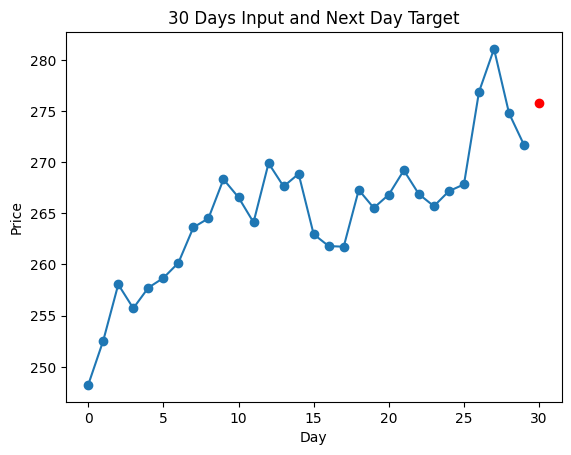

In [24]:
plt.plot(X[0], marker= 'o')
plt.plot(30, y[0], 'ro')
plt.xlabel("Day")
plt.ylabel("Price")
plt.title("30 Days Input and Next Day Target")
plt.show()

### Train & Test split

In [25]:
train_size = int(len(X)* 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [26]:
print(f'X_train shape: {X_train.shape} - X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape} - y_test shape: {y_test.shape}')

X_train shape: (1192, 30) - X_test shape: (298, 30)
y_train shape: (1192,) - y_test shape: (298,)


### pre-processing

In [48]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
X_train = feature_scaler.fit_transform(X_train)
X_test = feature_scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train = target_scaler.fit_transform(np.reshape(y_train, (-1, 1)))
y_test = target_scaler.transform(np.reshape(y_test, (-1, 1)))



### Random Forest

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

/Users/hasan.abbasi/Documents/hsn/students/nilu/ML/venv/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [50]:
print(f"input_days: {input_days} - output_days: {output_days}")
print(f"X_train shape: {X_train.shape} - X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape} - y_test shape: {y_test.shape}")
print(f"rf_pred shape: {rf_pred.shape}")

input_days: 30 - output_days: 1
X_train shape: (1192, 30) - X_test shape: (298, 30)
y_train shape: (1192, 1) - y_test shape: (298, 1)
rf_pred shape: (298,)


In [51]:
print("Train:", rf.score(X_train, y_train))
print("Test :", rf.score(X_test, y_test))

Train: 0.9997761862609702
Test : -1.3540939169534982


In [39]:
selected_index = 5
print(f"Test:", y_test[:selected_index])
print(f"RF predicted:", rf_pred[:selected_index])

Test: [1551.859985 1578.890015 1598.390015 1588.180054 1591.      ]
RF predicted: [1526.49113454 1523.23483302 1524.55247267 1528.76953395 1528.753573  ]


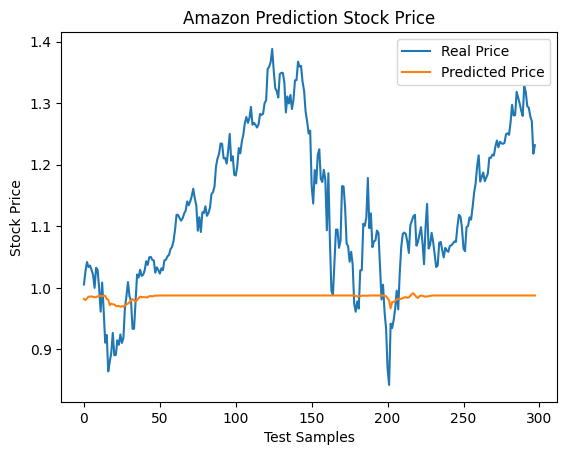

In [52]:
plt.plot(y_test, label="Real Price")
plt.plot(rf_pred, label="Predicted Price")
plt.title("Amazon Prediction Stock Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [53]:
selected_index = 5

selected_x = X_test[selected_index]
selected_y = y_test[selected_index]
selected_pred = rf_pred[selected_index]

print(f"Selected x: {selected_x} - Selected y: {selected_y} - Selected pred: {selected_pred}")


Selected x: [1.07928671 1.02473893 1.04633631 0.98948815 1.02169051 0.98215656
 0.91569036 0.90641211 0.945625   0.96940672 1.00013458 1.00914098
 0.99814988 1.01468272 1.02693523 1.02897023 1.04115828 1.05015745
 1.04198187 1.03666382 1.00865078 1.01222495 1.01912824 1.0124896
 1.01836979 1.02384942 1.04550327 1.06108657 1.05153238 1.04211422] - Selected y: [1.02928456] - Selected pred: 0.9859174122185786


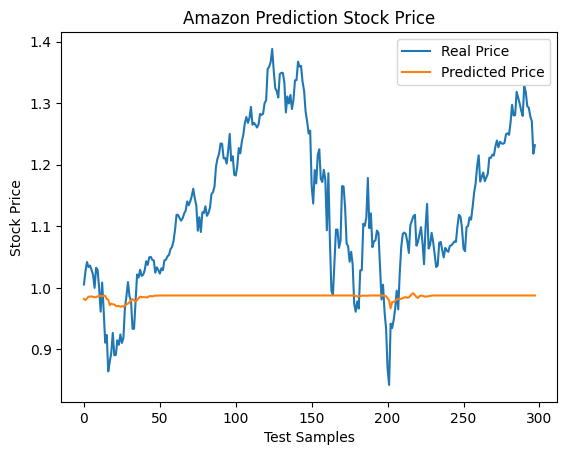

In [54]:
plt.plot(y_test, label="Real Price")
plt.plot(rf_pred, label="Predicted Price")
plt.title("Amazon Prediction Stock Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### SVM Regression

In [55]:
from sklearn.svm import SVR

svm = SVR(C=100, kernel="linear") #epsilon=1, gamma="scale"
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

/Users/hasan.abbasi/Documents/hsn/students/nilu/ML/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [56]:
print("Train:", svm.score(X_train, y_train))
print("Test:", svm.score(X_test, y_test))

Train: 0.988603368515486
Test: 0.5306574074237596


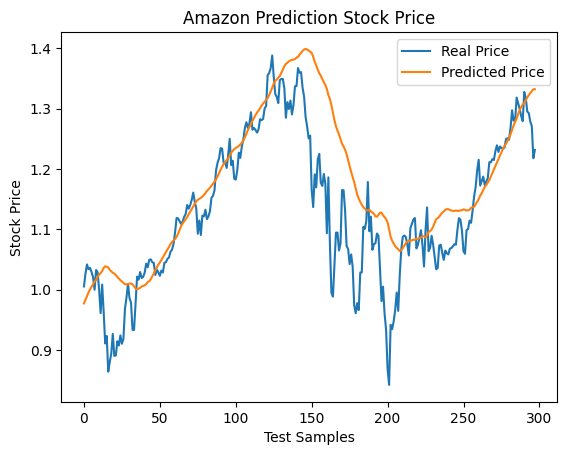

In [57]:
plt.plot(y_test, label="Real Price")
plt.plot(svm_pred, label="Predicted Price")
plt.title("Amazon Prediction Stock Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

#### input last 30 days and output next daye 

In [59]:
selected_index = 100

selected_x = X_test[selected_index]
selected_y = y_test[selected_index]
selected_pred = svm_pred[selected_index]

print(f"Selected x: {selected_x} - Selected y: {selected_y} - Selected pred: {selected_pred}")

Selected x: [1.32419164 1.33535435 1.33159871 1.28627874 1.25689899 1.19109697
 1.20172495 1.17627716 1.21070507 1.2093176  1.22107388 1.20440646
 1.20925868 1.21842491 1.24229912 1.24570485 1.2555683  1.27904533
 1.29364756 1.29442479 1.29658566 1.29318495 1.2535607  1.23223882
 1.22318658 1.24502444 1.27303534 1.22859499 1.23436555 1.19066632] - Selected y: [1.1823931] - Selected pred: 1.234800655693551


In [1260]:
print(f'y_train shape: {y_train.shape} - y_test shape: {y_test.shape}')

y_train shape: (1192,) - y_test shape: (298,)


In [1261]:
prcentage = 30/295*100
print(prcentage)

10.16949152542373


1 + 2 = 3
2 + 3 = 5
3 + 4 = 7
4 + 5 = 9
5 + 6 = 11
6 + 7 = 13


# Ali
# Train
1 + 2 = 3
2 + 3 = 5
3 + 4 = 7
4 + 5 = 9

# test
5 + 6 = 11
6 + 7 = 13

# mamad1
# Train
1 + 2 = 3
5 + 6 = 11
3 + 4 = 7
4 + 5 = 9
6 + 7 = 13

# test
4 + 5 = 9
2 + 3 = 5


# mamad2
# Train
1 + 2 = 3
5 + 6 = 11
3 + 4 = 7
4 + 5 = 9
6 + 7 = 13
12+15
15+16
41+42

# test
4 + 5 = 9
2 + 3 = 5

# emtehan
31 + 32 = 


# mehdi
1 + 2 = 3
2 + 3 = 5
3 + 4 = 7
4 + 5 = 9
5 + 6 = 11
6 + 7 = 13